In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Repertorio/Simulacion_Molecular')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc,rcParams
from IPython.display import Image

# Modelo del oscilador armónico

El oscilador armónico clásico constituye un movimiento repetitivo, en el que una masa se desplaza de un lugar a otro en un movimiento que obedece la ley de Hooke. Dada una masa $m$, la ley de Hooke establece que en el caso de un desplazamiento $x$ unidimensional a partir de una posición de equilibrio, la fuerza $F$ que actúa en contra del desplazamiento (es decir, la fuerza que actúa para restituir la masa punto de equilibrio) es proporcional al desplazamiento:

$$F = -kx$$

donde k recibe el nombre de constante de fuerza.

Bibliografía:
- Castañeta, H., y Nogales, J. (2016). *Oscilador armónico cuántico: la energía vibracional en las moléculas*. Rev.Cs.Farm. y Bioq, 4(*1*), 73-84.

## Modelo de enlace de una molécula diatómica

In [3]:
%%file enlace.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc,rcParams

rc('animation',html='jshtml')
rcParams['animation.embed_limit'] = 2**128

m = 1
L = 5 # lado
l = 1

posi = np.random.uniform(0,L,size=(2))
ang = np.random.choice(np.linspace(0,2*np.pi,100))

posj = posi+l*[np.cos(ang),np.sin(ang)]

vels = np.random.rand(2,2)-0.5

pos = np.array([posi,posj])

''' Propiedades periódicas a la frontera
'''

def pperiod(pos,L):
  cmx,cmy = 0.5*(pos[0][0]+pos[1][0]),0.5*(pos[0][1]+pos[1][1])
  #cm = pos.mean(axis=0)
  if cmx>L:
       pos[0][0]-=L
       pos[1][0]-=L
  elif cmx<0:
       pos[0][0]+=L
       pos[1][0]+=L

  if cmy>L:
       pos[0][1]-=L
       pos[1][1]-=L
  elif cmy<0:
       pos[0][1]+=L
       pos[1][1]+=L
  return pos


''' Representación de las partículas '''
def circulos(ax,pos,r):
       circ = plt.Circle((pos[0][0],pos[0][1]),r,color='coral',ec='k')
       ax.add_patch(circ)
       circ = plt.Circle((pos[1][0],pos[1][1]),r,color='indigo',ec='k')
       ax.add_patch(circ)

''' Cálculo de la fuerza'''

def fuerza_enlace(pos,l):
  k=10
  fuerza = np.zeros((2,2))
  vecr = pos[1]-pos[0]
  r = np.linalg.norm(vecr)
  unir = vecr/r
  f1 = k*(r-l)*unir
  f2 = -k*(r-l)*unir
  fuerza[0]=f1
  fuerza[1]=f2
  return fuerza

#################################
fig,ax = plt.subplots(figsize=(3,3))


npasos = 1000000

t = 0
dt = 0.00001 # muy pequeño
G = []
conteo = 0
R = 0.2
for i in range(npasos):
   t += dt # t = t + dt
   f = fuerza_enlace(pos,l) # Calcula la fuerza
   acel = f/m
   vels = vels + acel*dt # La velocidad no es constante
   pos = pos + vels*dt # Este paso es la integración numérica

   pperiod(pos,L)
   if i%(npasos/100)==0:
      G.append(pos)
   if i%(npasos/10)==0:
      conteo += 1
      print('>'*conteo+'-'*(10-conteo))

def pelicula(i):
    ax.clear()
    ax.set_aspect(1)
    ax.axis('off')
    plt.xlim(0,L) # ax.set_xlim(0,L)
    plt.ylim(0,L) # ax.set_ylim(0,L)
    plt.plot([G[i][0][0],G[i][1][0]],[G[i][0][1],G[i][1][1]],c='gray',zorder=-1)
    circulos(ax,G[i],R)
    #plt.scatter(G[i][:,0],G[i][:,1],s=100,c=range(N),cmap='rainbow',ec='k')

anim = FuncAnimation(fig,pelicula,frames=range(len(G)))
#anim.save('enlace.gif')
anim.save('enlace.gif', writer='pillow', fps=50)

Overwriting enlace.py


>---------
>>--------
>>>-------
>>>>------
>>>>>-----
>>>>>>----
>>>>>>>---
>>>>>>>>--
>>>>>>>>>-
>>>>>>>>>>


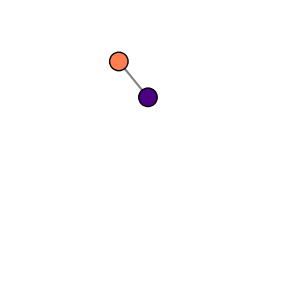

In [4]:
! python enlace.py
Image('enlace.gif')

## Actividad 1. Haz una animación de la molécula diatómica cambiando su constante armónica $k$ a 1, 10 y 100. compara y discute lo observado en aprox. un párrafo.

## Actividad 2. Programar el resorte

In [5]:
%%file enlace_espiral.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc,rcParams
from IPython.display import Image

rc('animation',html='jshtml')
rcParams['animation.embed_limit'] = 2**128

m = 1
L = 5 # lado
l = 1

posi = np.random.uniform(0,L,size=(2))
ang = np.random.choice(np.linspace(0,2*np.pi,100))

posj = posi+l*[np.cos(ang),np.sin(ang)]

vels = np.random.rand(2,2)-0.5

pos = np.array([posi,posj])

''' Propiedades periódicas a la frontera
'''

def pperiod(pos,L):
  cmx,cmy = 0.5*(pos[0][0]+pos[1][0]),0.5*(pos[0][1]+pos[1][1])
  #cm = pos.mean(axis=0)
  if cmx>L:
       pos[0][0]-=L
       pos[1][0]-=L
  elif cmx<0:
       pos[0][0]+=L
       pos[1][0]+=L

  if cmy>L:
       pos[0][1]-=L
       pos[1][1]-=L
  elif cmy<0:
       pos[0][1]+=L
       pos[1][1]+=L
  return pos


''' Representación de las partículas '''
def circulos(ax,pos,r):
       circ = plt.Circle((pos[0][0],pos[0][1]),r,color='coral',ec='k')
       ax.add_patch(circ)
       circ = plt.Circle((pos[1][0],pos[1][1]),r,color='indigo',ec='k')
       ax.add_patch(circ)

''' Cálculo de la fuerza'''

def fuerza_enlace(pos,l):
  k=10
  fuerza = np.zeros((2,2))
  vecr = pos[1]-pos[0]
  r = np.linalg.norm(vecr)
  unir = vecr/r
  f1 = k*(r-l)*unir
  f2 = -k*(r-l)*unir
  fuerza[0]=f1
  fuerza[1]=f2
  return fuerza


#
def espiral(ax,x1,y1,x2,y2,R):
    theta = np.linspace(0,16*np.pi,100)

    dx = np.linspace(x1,x2,100)
    dy = np.linspace(y1,y2,100)

    X = 0.5*R*np.cos(theta)+dx
    Y = 0.5*R*np.sin(theta)+dy
    ax.plot(X,Y,c='k',zorder=-1)

#################################
fig,ax = plt.subplots(figsize=(3,3))


npasos = 1000000

t = 0
dt = 0.00001 # muy pequeño
G = []
conteo = 0
R = 0.2
for i in range(npasos):
   t += dt # t = t + dt
   f = fuerza_enlace(pos,l) # Calcula la fuerza
   acel = f/m
   vels = vels + acel*dt # La velocidad no es constante
   pos = pos + vels*dt # Este paso es la integración numérica

   pperiod(pos,L)
   if i%(npasos/100)==0:
      G.append(pos)
   if i%(npasos/10)==0:
      conteo += 1
      print('>'*conteo+'-'*(10-conteo))

def pelicula(i):
    ax.clear()
    ax.set_aspect(1)
    ax.axis('off')
    plt.xlim(0,L) # ax.set_xlim(0,L)
    plt.ylim(0,L) # ax.set_ylim(0,L)
    espiral(ax,G[i][0][0],G[i][0][1],G[i][1][0],G[i][1][1],R)
    #plt.plot([G[i][0][0],G[i][1][0]],[G[i][0][1],G[i][1][1]],c='gray',zorder=-1)
    circulos(ax,G[i],R)
    #plt.scatter(G[i][:,0],G[i][:,1],s=100,c=range(N),cmap='rainbow',ec='k')

anim = FuncAnimation(fig,pelicula,frames=range(len(G)))
anim.save('enlace_espiral.gif', writer='pillow', fps=50)


Overwriting enlace_espiral.py


>---------
>>--------
>>>-------
>>>>------
>>>>>-----
>>>>>>----
>>>>>>>---
>>>>>>>>--
>>>>>>>>>-
>>>>>>>>>>


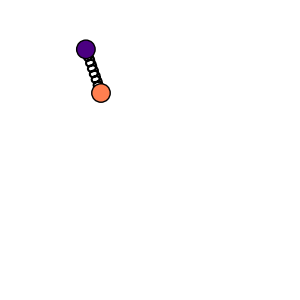

In [6]:
! python enlace_espiral.py
Image('enlace_espiral.gif')

In [7]:
def espiral(ax,x1,y1,x2,y2,R):
  theta = np.linspace(0,16*np.pi,100)

  dx = np.linspace(x1,x2,100)
  dy = np.linspace(y1,y2,100)

  X = 0.5*R*np.cos(theta)+dx
  Y = 0.5*R*np.sin(theta)+dy
  ax.plot(X,Y,c='silver',zorder=-1)

  fig,ax = plt.subplots(figsize=(2,2))
  ax.set_aspect(1)
  espiral(ax,1,2,3,3,R)

# Campo de fuerza

![picture](http://mmb.irbbarcelona.org/NAFlex/htmlib/help/img/MDForceField.png)

In [8]:
# Modelo de agua: TIP3P

%%file enlace_agua.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc,rcParams

rc('animation',html='jshtml')
rcParams['animation.embed_limit'] = 2**128

m = 1
L = 5 # lado
l = 0.9584
l2 = 1.51

posO = np.random.uniform(0,L,size=(2))
ang0 = np.radians(104.5)

ang = np.random.choice(np.linspace(0,2*np.pi,100))

posH1 = posO + [l*np.cos(ang),np.sin(ang)]
posH2 = posO + [l*np.cos(ang+ang0),np.sin(ang+ang0)]

dist = np.linalg.norm(posH2-posH1)
print(dist)
pos = np.array([posO,posH1,posH2])

vels = np.random.rand(3,2)-0.5

''' Propiedades periódicas a la frontera
'''

def pperiod(pos,L):
  cmx = (16*pos[0][0]+1*pos[1][0]+1*pos[2][0])/18
  cmy = (16*pos[0][1]+1*pos[1][1]+1*pos[2][1])/18
  if cmx>L:
       pos[0][0]-=L
       pos[1][0]-=L
       pos[2][0]-=L
  elif cmx<0:
       pos[0][0]+=L
       pos[1][0]+=L
       pos[2][0]-=L
  if cmy>L:
       pos[0][1]-=L
       pos[1][1]-=L
       pos[2][1]-=L
  elif cmy<0:
       pos[0][1]+=L
       pos[1][1]+=L
       pos[2][1]-=L
  return pos


''' Representación de las partículas '''
def circulos(ax,pos,r):
       0.32,0.73
       circ = plt.Circle((pos[0][0],pos[0][1]),r,color='red',ec='k')
       ax.add_patch(circ)
       circ = plt.Circle((pos[1][0],pos[1][1]),(0.32/0.73)*r,color='white',ec='k')
       ax.add_patch(circ)
       circ = plt.Circle((pos[2][0],pos[2][1]),(0.32/0.73)*r,color='white',ec='k')
       ax.add_patch(circ)

''' Cálculo de la fuerza'''

def fuerza_enlace(pos,l,l2):
  # Enlace O-H1
  k=10
  fuerza = np.zeros((3,2))
  vecr = pos[1]-pos[0]
  r = np.linalg.norm(vecr)
  unir = vecr/r
  f1 = k*(r-l)*unir
  f2 = -k*(r-l)*unir
  fuerza[0]+=f1
  fuerza[1]+=f2

  # Enlace O-H2
  k=10
  vecr = pos[2]-pos[0]
  r = np.linalg.norm(vecr)
  unir = vecr/r
  f1 = k*(r-l)*unir
  f2 = -k*(r-l)*unir
  fuerza[0]+=f1
  fuerza[2]+=f2

  # Tercer enlace
  k=10
  vecr = pos[2]-pos[1]
  r = np.linalg.norm(vecr)
  unir = vecr/r
  f1 = k*(r-l2)*unir
  f2 = -k*(r-l2)*unir
  fuerza[1]+=f1
  fuerza[2]+=f2
  return fuerza

# Enlaces en espiral
def espiral(ax,x1,y1,x2,y2,R):
    theta = np.linspace(0,16*np.pi,100)

    dx = np.linspace(x1,x2,100)
    dy = np.linspace(y1,y2,100)

    X = 0.5*R*np.cos(theta)+dx
    Y = 0.5*R*np.sin(theta)+dy
    ax.plot(X,Y,c='k',zorder=-1)

#################################
fig,ax = plt.subplots(figsize=(3,3))


npasos = 1000000

t = 0
dt = 0.00001 # muy pequeño
G = []
conteo = 0
R = 0.2
for i in range(npasos):
   t += dt # t = t + dt
   f = fuerza_enlace(pos,l,l2) # Calcula la fuerza
   acel = f/m
   vels = vels + acel*dt # La velocidad no es constante
   pos = pos + vels*dt # Este paso es la integración numérica

   pperiod(pos,L)
   if i%(npasos/100)==0:
      G.append(pos)
   if i%(npasos/10)==0:
      conteo += 1
      print('>'*conteo+'-'*(10-conteo))

def pelicula(i):
    ax.clear()
    ax.set_aspect(1)
    ax.axis('off')
    plt.xlim(0,L) # ax.set_xlim(0,L)
    plt.ylim(0,L) # ax.set_ylim(0,L)
    espiral(ax,G[i][0][0],G[i][0][1],G[i][1][0],G[i][1][1],R)
    espiral(ax,G[i][0][0],G[i][0][1],G[i][2][0],G[i][2][1],R)
    #plt.plot([G[i][0][0],G[i][1][0]],[G[i][0][1],G[i][1][1]],c='gray',zorder=-1)
    circulos(ax,G[i],R)
    #plt.scatter(G[i][:,0],G[i][:,1],s=100,c=range(N),cmap='rainbow',ec='k')

anim = FuncAnimation(fig,pelicula,frames=range(len(G)))
anim.save('enlace_agua.gif', writer='pillow', fps=50)

Overwriting enlace_agua.py


1.5811835035223982
>---------
>>--------
>>>-------
>>>>------
>>>>>-----
>>>>>>----
>>>>>>>---
>>>>>>>>--
>>>>>>>>>-
>>>>>>>>>>


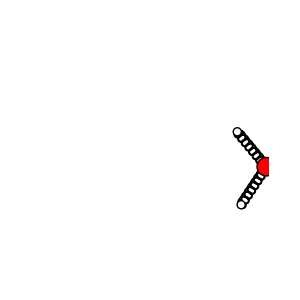

In [9]:
! python enlace_agua.py
Image('enlace_agua.gif')

## Actividad 3. Programar una simulación de la molécula $CO_{2}$

In [10]:
%%file enlace_CO2.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc, rcParams

rc('animation', html='jshtml')
rcParams['animation.embed_limit'] = 2**128

# Parámetros físicos y geométricos del CO2
m = 1
L = 8 # Lado de la caja
l = 1.16 # Longitud de enlace C=O
l2 = 2.32 # Distancia O-O para molécula lineal (1.16 * 2)

# Posicionamiento inicial
posC = np.random.uniform(0, L, size=(2)) # Átomo central (Carbono)
ang0 = np.radians(180) # Geometría lineal del CO2
ang_orientacion = np.random.choice(np.linspace(0, 2*np.pi, 100)) # Orientación aleatoria

# Posiciones de los Oxígenos basándose en el Carbono central
posO1 = posC + [l * np.cos(ang_orientacion), l * np.sin(ang_orientacion)]
posO2 = posC + [l * np.cos(ang_orientacion + ang0), l * np.sin(ang_orientacion + ang0)]

pos = np.array([posC, posO1, posO2]) # Orden: C, O1, O2
vels = np.random.rand(3, 2) - 0.5 # Velocidades iniciales

def pperiod(pos, L):
    """ Propiedades periódicas basadas en el centro de masa """
    # Masas aproximadas: C=12, O=16. Aquí se usa una aproximación de pesos
    cmx = (12 * pos[0][0] + 16 * pos[1][0] + 16 * pos[2][0]) / 44
    cmy = (12 * pos[0][1] + 16 * pos[1][1] + 16 * pos[2][1]) / 44

    if cmx > L: pos[:, 0] -= L
    elif cmx < 0: pos[:, 0] += L
    if cmy > L: pos[:, 1] -= L
    elif cmy < 0: pos[:, 1] += L
    return pos

def circulos(ax, pos, r):
    """ Representación: C (negro) y O (rojo) """
    # Carbono central
    circC = plt.Circle((pos[0][0], pos[0][1]), r, color='black', ec='k')
    ax.add_patch(circC)
    # Oxígenos
    circO1 = plt.Circle((pos[1][0], pos[1][1]), r * 0.9, color='red', ec='k')
    circO2 = plt.Circle((pos[2][0], pos[2][1]), r * 0.9, color='red', ec='k')
    ax.add_patch(circO1)
    ax.add_patch(circO2)

def fuerza_enlace(pos, l, l2):
    """ Cálculo de fuerzas armónicas """
    k = 10 # Constante de fuerza
    fuerza = np.zeros((3, 2))

    # Enlaces C-O1 y C-O2
    for i in [1, 2]:
        vecr = pos[i] - pos[0]
        r = np.linalg.norm(vecr)
        unir = vecr / r
        f_mag = k * (r - l) * unir
        fuerza[0] += f_mag
        fuerza[i] -= f_mag

    # Restricción angular (distancia O1-O2) para mantener linealidad
    vecr_oo = pos[2] - pos[1]
    r_oo = np.linalg.norm(vecr_oo)
    unir_oo = vecr_oo / r_oo
    f_oo = k * (r_oo - l2) * unir_oo
    fuerza[1] += f_oo
    fuerza[2] -= f_oo

    return fuerza

def espiral(ax, x1, y1, x2, y2, R):
    theta = np.linspace(0, 16 * np.pi, 100)
    dx = np.linspace(x1, x2, 100)
    dy = np.linspace(y1, y2, 100)
    X = 0.5 * R * np.cos(theta) + dx
    Y = 0.5 * R * np.sin(theta) + dy
    ax.plot(X, Y, c='k', zorder=-1, lw=1)

# Simulación
fig, ax = plt.subplots(figsize=(3, 3))
npasos = 1000000
dt = 0.00001
G = []
R = 0.2

for i in range(npasos):
    f = fuerza_enlace(pos, l, l2)
    acel = f / m
    vels += acel * dt
    pos += vels * dt
    pperiod(pos, L)
    if i % (npasos / 100) == 0:
        G.append(pos.copy())

def pelicula(i):
    ax.clear()
    ax.set_aspect(1)
    ax.axis('off')
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    # Dibujar resortes entre C-O1 y C-O2
    espiral(ax, G[i][0][0], G[i][0][1], G[i][1][0], G[i][1][1], R)
    espiral(ax, G[i][0][0], G[i][0][1], G[i][2][0], G[i][2][1], R)
    circulos(ax, G[i], R)

anim = FuncAnimation(fig, pelicula, frames=range(len(G)))
anim.save('enlace_CO2.gif', writer='pillow', fps=50)


Overwriting enlace_CO2.py


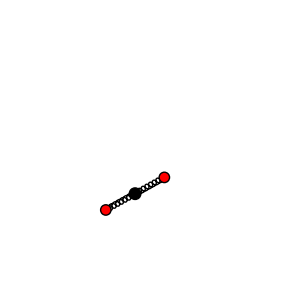

In [11]:
! python enlace_CO2.py
Image('enlace_CO2.gif')